## Physical insight into the optimized PVs

## 1) Setup

In [32]:
%run -i imports.py
import pandas as pd
import numpy as np
%matplotlib inline
data_tag = 'M2'
target_variables_indices = [0, 5, 6, 7, 8, 9, 10, 13, 14, 15, 17, 20, 23, 24, 25, 26]
pure_streams = True #DO NOT modify it, unless you want to perform a "non-trainable pure streams analysis" (Refer to Section 3.4. The impact of training data preprocessing of https://doi.org/10.1016/j.combustflame.2025.114152)
pure_streams_prefix = 'tps'
data_type = 'FPF'
%run -i ../scripts/fpf-load-data.py

Python==3.10.13

numpy==1.26.2
pandas==2.1.3
scipy==1.11.4
scikit-learn==1.3.2
PCAfold==2.2.0

Using: T, H2, H, O, OH, H2O, O2, NH3, NH2, NO2, NH, NO, N2O, CO2, CO, CH4 as target state variables at the decoder output.

9303 observations
56 state variables


<Figure size 640x480 with 0 Axes>

In [33]:
def populate_weights_matrix(model_weights_filename, random_seeds_list):

    Yi = state_space[:, 5:]

    n_species = Yi.shape[1]

    weights_collected = np.zeros((len(random_seeds_list), n_species))

    for i, random_seed in enumerate(random_seeds_list):

        hf = h5py.File(model_weights_filename + str(random_seed) + '.h5', 'r')

        current_weights = np.array(hf.get('0'))
        hf.close()

        current_weights = (np.abs(current_weights)/ np.max(np.abs(current_weights)))
        weights_collected[i, :] = current_weights.ravel()

    return weights_collected

In [34]:
def populate_max_matrix(model_weights_filename, random_seeds_list):

    Yi = state_space[:, 5:]
    
    n_species = Yi.shape[1]

    max_collected = np.zeros((len(random_seeds_list), n_species))

    for i, random_seed in enumerate(random_seeds_list):

        hf = h5py.File(model_weights_filename + str(random_seed) + '.h5','r')

        current_weights = np.array(hf.get('0'))
        hf.close()

        current_weights = current_weights.ravel()
        scaled_state_space = (Yi * np.abs(current_weights))
        current_max = np.max(scaled_state_space, axis=0)
        max_collected[i, :] = (current_max/ np.max(current_max))

    return max_collected


In [35]:
def populate_normalized_basis(model_weights_filename, random_seeds_list):
    Yi = state_space[:, 5:]
        
    n_species = Yi.shape[1]
    
    normalized_basis_collected = np.zeros((len(random_seeds_list), n_species))

    for i, random_seed in enumerate(random_seeds_list):
    
        hf = h5py.File(model_weights_filename + str(random_seed) + '.h5','r')
            
        current_weights = np.array(hf.get('0'))
        hf.close()

        optimized_basis_normalized = ((current_weights - np.min(current_weights)) / (np.max(current_weights) - np.min(current_weights)))

        # # Flatten current_weights
        # current_weights_normalized_flat = np.asarray(optimized_basis_normalized).ravel()

        normalized_basis_collected[i, :] = optimized_basis_normalized.ravel()
        
    return normalized_basis_collected



In [36]:
def plot_violins(weights_collected):

    fig, ax = plt.subplots(figsize=(10, 3))

    n_species = weights_collected.shape[1]
    xrange = np.arange(n_species)

    violin_parts = ax.violinplot(weights_collected,positions=xrange,widths=0.8)

    ax.scatter(xrange,np.median(weights_collected, axis=0), s=20,c='k')

    ax.set_xticks(xrange)
    ax.set_xticklabels(tex_names,rotation=90,fontsize=10)

    ax.tick_params(axis='y', labelsize=18)

    ax.set_ylabel(r'$|w_i|$ [$-$]',fontsize=20)

    ax.grid(alpha=0.3, zorder=1)
    ax.set_yticks([0, 0.5, 1])

    for pc in violin_parts['bodies']:
        pc.set_facecolor('red')
        pc.set_edgecolor('red')

    for partname in ('cbars', 'cmins', 'cmaxes'):
        vp = violin_parts[partname]
        vp.set_edgecolor('k')
        vp.set_linewidth(1.5)

    plt.tight_layout()
    plt.show()
        

In [37]:
def plot_normalized_violins(weights_collected):

    fig, ax = plt.subplots(figsize=(10, 3))

    n_species = weights_collected.shape[1]
    xrange = np.arange(n_species)

    violin_parts = ax.violinplot(weights_collected,positions=xrange,widths=0.8)

    ax.scatter(xrange,np.median(weights_collected, axis=0), s=20,c='k')

    ax.set_xticks(xrange)
    ax.set_xticklabels(tex_names,rotation=90,fontsize=10)

    ax.tick_params(axis='y', labelsize=18)

    ax.set_ylabel(r'$w_i$ [$-$]',fontsize=20)

    ax.grid(alpha=0.3, zorder=1)
    ax.set_yticks([0, 0.5, 1])

    for pc in violin_parts['bodies']:
        pc.set_facecolor('red')
        pc.set_edgecolor('red')

    for partname in ('cbars', 'cmins', 'cmaxes'):
        vp = violin_parts[partname]
        vp.set_edgecolor('k')
        vp.set_linewidth(1.5)

    plt.tight_layout()
    plt.show()

In [38]:
def plot_max_violins(max_collected):

    fig, ax = plt.subplots(figsize=(10, 3))

    n_species = max_collected.shape[1]
    xrange = np.arange(n_species)

    violin_parts = ax.violinplot(max_collected, positions=xrange,widths=0.8)

    ax.scatter(xrange, np.median(max_collected, axis=0), s=20, c='k')

    ax.set_xticks(xrange)
    ax.set_xticklabels(tex_names, rotation=90, fontsize=10)

    ax.tick_params(axis='y', labelsize=18)

    ax.set_ylabel(r'$\max(|w_i| \cdot Y_i)$ [$-$]', fontsize=15)

    ax.grid(alpha=0.3, zorder=1)
    ax.set_yticks([0, 0.5, 1])

    for pc in violin_parts['bodies']:
        pc.set_facecolor('red')
        pc.set_edgecolor('red')

    for partname in ('cbars', 'cmins', 'cmaxes'):
        vp = violin_parts[partname]
        vp.set_edgecolor('k')
        vp.set_linewidth(1.5)

    plt.tight_layout()
    plt.show()


## 2) Distribution of the scaled mass fraction

In [39]:
### Select the seed(s) you want to analyse
# random_seeds_list = [i for i in range(0,9)]
random_seeds_list = [0]

In [40]:
tex_names = tex_names[5::]

In [41]:
### Adapt to your own best-model-weights.h5 file
model_weights_filename = '../scripts/f-PV-' + pure_streams_prefix + '-FPF-M2-target-T-H2-H-O-OH-H2O-O2-NH3-NH2-NO2-NH-NO-N2O-CO2-CO-CH4-RandomNormal-e-300000-CD-300000-lr-0.01-alr-0.001-scale-none-darch-0-10-10-rho-0.9-mom-0.5-momcent-no-best-model-weights-rs-'

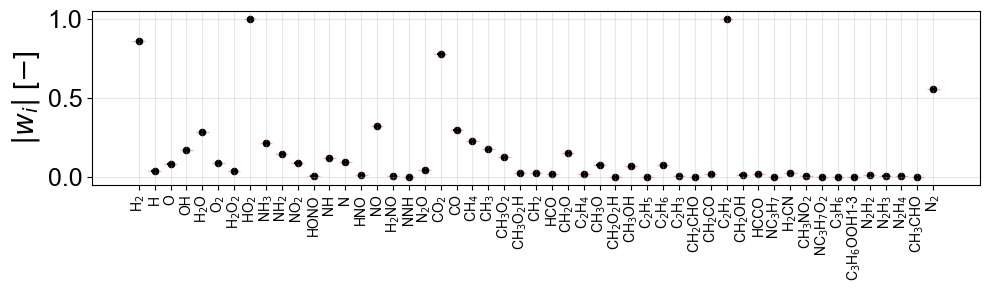

In [42]:
import matplotlib.pyplot as plt
weights_collected = populate_weights_matrix(model_weights_filename, random_seeds_list)
plot_violins(weights_collected)

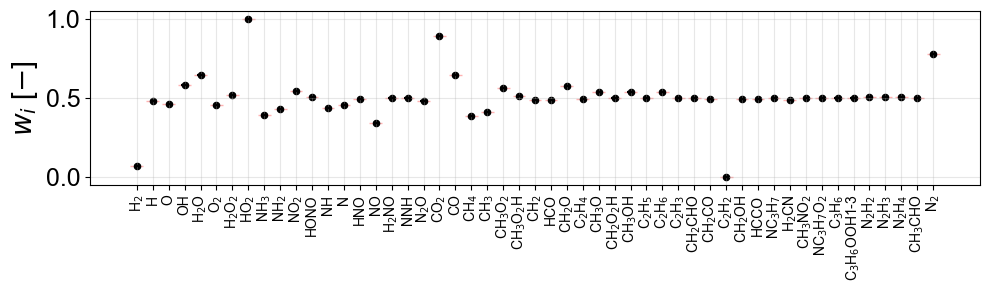

In [43]:
normalized_basis_collected = populate_normalized_basis(model_weights_filename, random_seeds_list)
plot_normalized_violins(normalized_basis_collected)

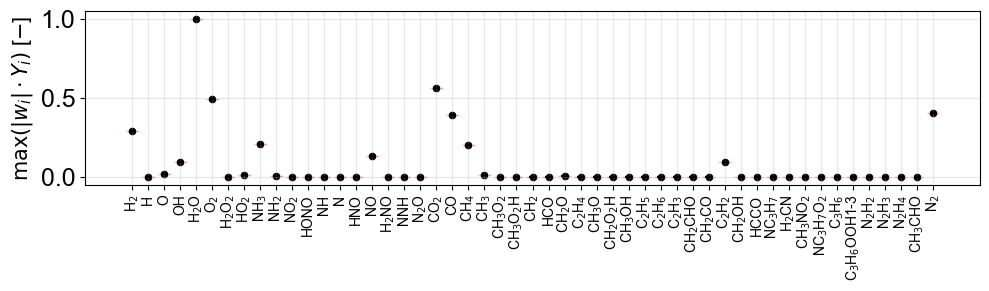

In [44]:
max_collected = populate_max_matrix(model_weights_filename, random_seeds_list)
plot_max_violins(max_collected)